First 5 rows of the dataset:
   hour_of_day cash_type  money    coffee_name Time_of_Day Weekday Month_name  \
0           10      card   38.7          Latte     Morning     Fri        Mar   
1           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
2           12      card   38.7  Hot Chocolate   Afternoon     Fri        Mar   
3           13      card   28.9      Americano   Afternoon     Fri        Mar   
4           13      card   38.7          Latte   Afternoon     Fri        Mar   

   Weekdaysort  Monthsort        Date     Time  Unnamed: 11  Unnamed: 12  \
0            5          3  03-01-2024  15:50.5          NaN          NaN   
1            5          3  03-01-2024  19:22.5          NaN          NaN   
2            5          3  03-01-2024  20:18.1          NaN          NaN   
3            5          3  03-01-2024  46:33.0          NaN          NaN   
4            5          3  03-01-2024  48:14.6          NaN          NaN   

                           

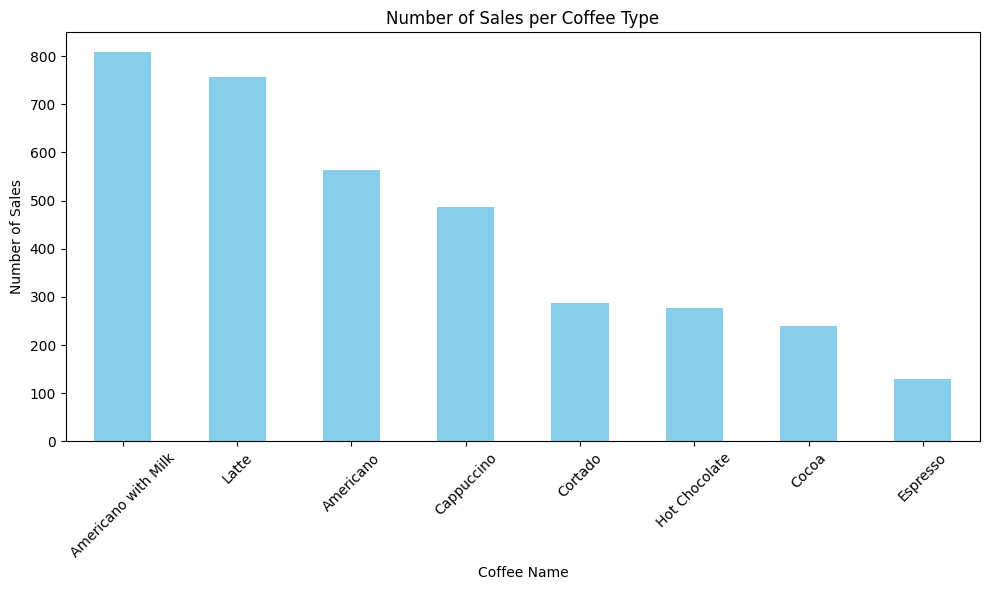

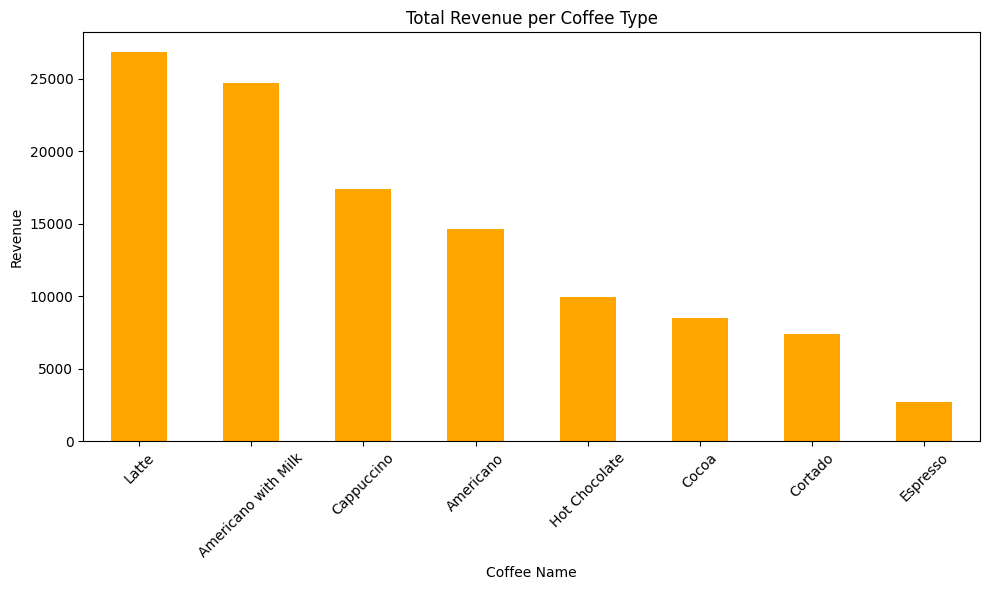

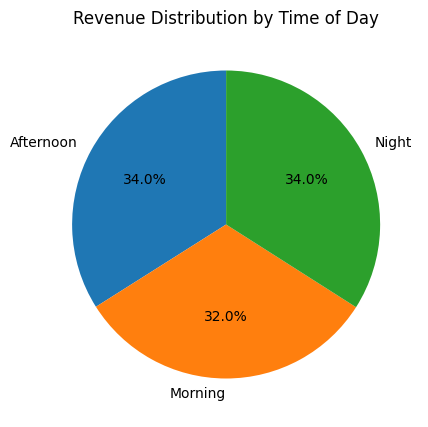

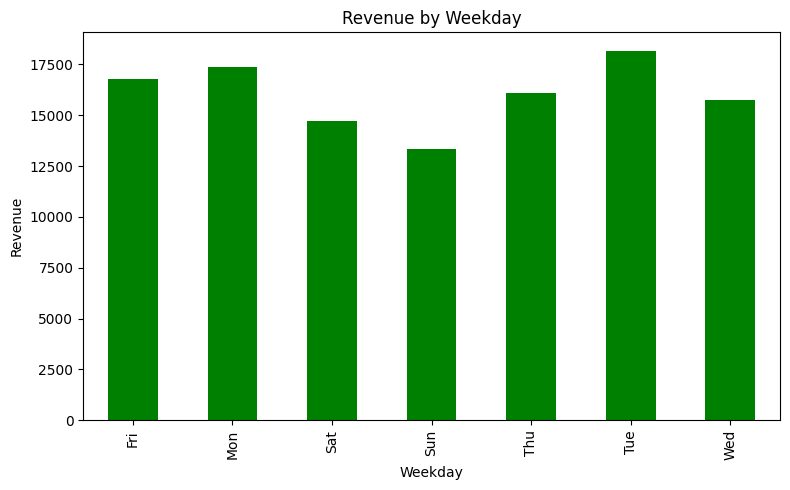


Insights:
- The most popular coffee type by count is: Americano with Milk
- The coffee type generating the highest revenue is: Latte
- The time of day with the highest revenue is: Night
- The weekday with the highest revenue is: Tue


In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load the CSV data
df = pd.read_csv('Coffe_sales.csv')

# Step 2: Inspect the data
print("First 5 rows of the dataset:")
print(df.head())
print("\nData summary:")
print(df.info())

# Step 3: Clean the data if necessary
# Remove empty unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert 'money' to numeric (in case of any issues)
df['money'] = pd.to_numeric(df['money'], errors='coerce')

# Step 4: Basic descriptive statistics
print("\nBasic statistics for money column:")
print(df['money'].describe())

# Step 5: Analyze sales by coffee type
coffee_sales_count = df['coffee_name'].value_counts()
coffee_sales_revenue = df.groupby('coffee_name')['money'].sum().sort_values(ascending=False)

print("\nNumber of sales per coffee type:")
print(coffee_sales_count)

print("\nTotal revenue per coffee type:")
print(coffee_sales_revenue)

# Step 6: Analyze sales by time of day
time_of_day_sales = df.groupby('Time_of_Day')['money'].sum()
print("\nTotal revenue by Time of Day:")
print(time_of_day_sales)

# Step 7: Analyze sales by weekday
weekday_sales = df.groupby('Weekday')['money'].sum()
print("\nTotal revenue by Weekday:")
print(weekday_sales)

# Step 8: Visualizations
plt.figure(figsize=(10, 6))
coffee_sales_count.plot(kind='bar', color='skyblue')
plt.title("Number of Sales per Coffee Type")
plt.xlabel("Coffee Name")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
coffee_sales_revenue.plot(kind='bar', color='orange')
plt.title("Total Revenue per Coffee Type")
plt.xlabel("Coffee Name")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
time_of_day_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Revenue Distribution by Time of Day")
plt.ylabel("")
plt.show()

plt.figure(figsize=(8, 5))
weekday_sales.plot(kind='bar', color='green')
plt.title("Revenue by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

# Step 9: Insights
print("\nInsights:")
print("- The most popular coffee type by count is:", coffee_sales_count.idxmax())
print("- The coffee type generating the highest revenue is:", coffee_sales_revenue.idxmax())
print("- The time of day with the highest revenue is:", time_of_day_sales.idxmax())
print("- The weekday with the highest revenue is:", weekday_sales.idxmax())